In [3]:
# RailGuard Model Comparison

## YOLO11 vs YOLOv8

Comparison of binary railway-defect object detection models trained and evaluated using the RailGuard dataset.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = ["YOLO11", "YOLOv8"]

# Confirmed validation metrics
validation = pd.DataFrame({
    "Model": models,
    "Precision": [0.444, 0.429],
    "Recall": [0.416, 0.378],
    "mAP50": [0.389, 0.355],
    "mAP50-95": [0.145, 0.129]
})

# Confirmed test metrics
testing = pd.DataFrame({
    "Model": models,
    "Precision": [0.477, 0.4316],
    "Recall": [0.406, 0.4258],
    "F1 Score": [0.439, 0.4287],
    "mAP50": [0.400, 0.3975],
    "mAP50-95": [0.144, 0.1372]
})

# Separate error analysis
error_analysis = pd.DataFrame({
    "Model": models,
    "True Positives": [520, 463],
    "False Positives": [485, 398],
    "False Negatives": [974, 1031]
})

display(validation)
display(testing)
display(error_analysis)

,Model,Precision,Recall,mAP50,mAP50-95
0,YOLO11,0.444,0.416,0.389,0.145
1,YOLOv8,0.429,0.378,0.355,0.129


,Model,Precision,Recall,F1 Score,mAP50,mAP50-95
0,YOLO11,0.4770,0.4060,0.4390,0.4000,0.1440
1,YOLOv8,0.4316,0.4258,0.4287,0.3975,0.1372


,Model,True Positives,False Positives,False Negatives
0,YOLO11,520,485,974
1,YOLOv8,463,398,1031


In [ ]:
## Validation Metrics Comparison

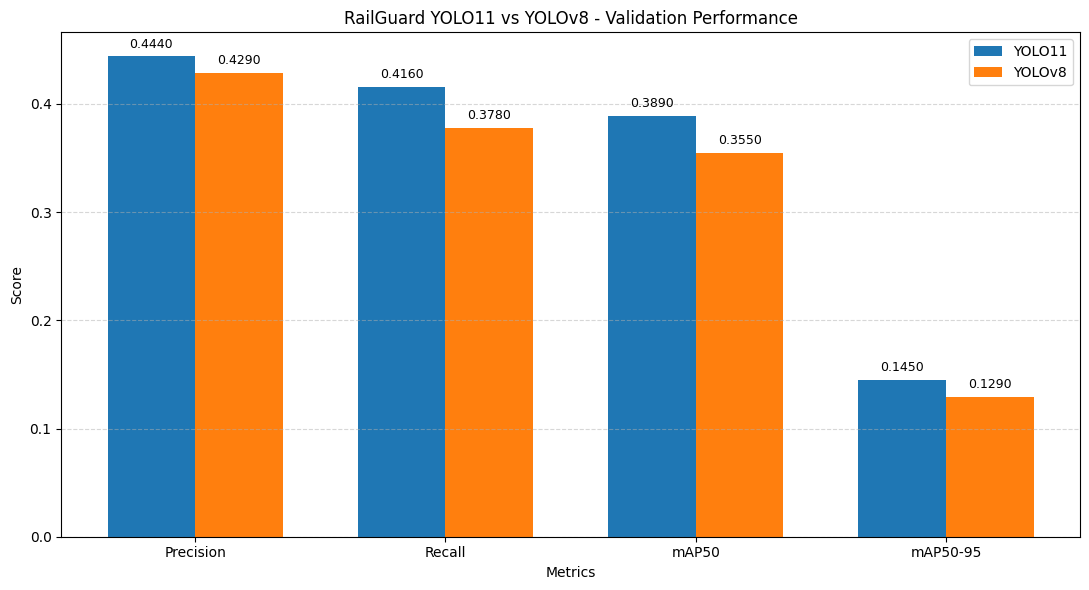

In [5]:
metric_names = ["Precision", "Recall", "mAP50", "mAP50-95"]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(11, 6))

for i, model in enumerate(models):
    values = validation.loc[
        validation["Model"] == model,
        metric_names
    ].values[0]

    bars = plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.4f}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("RailGuard YOLO11 vs YOLOv8 - Validation Performance")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
## Testing Metrics Comparison

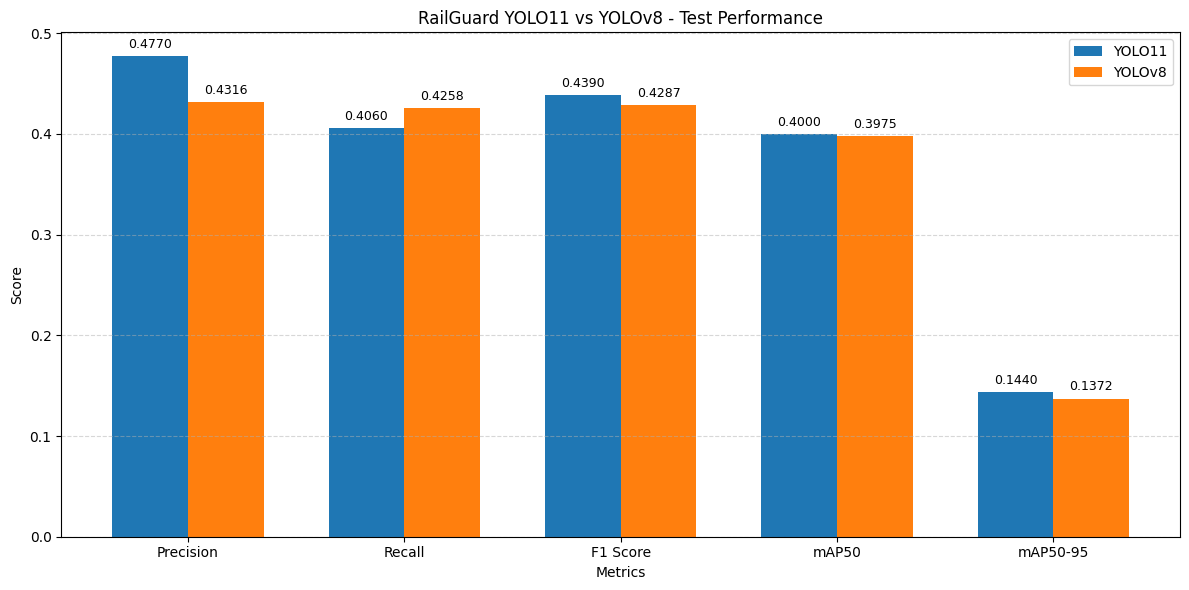

In [6]:
metric_names = [
    "Precision",
    "Recall",
    "F1 Score",
    "mAP50",
    "mAP50-95"
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    values = testing.loc[
        testing["Model"] == model,
        metric_names
    ].values[0]

    bars = plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.4f}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("RailGuard YOLO11 vs YOLOv8 - Test Performance")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
## Error Analysis Comparison

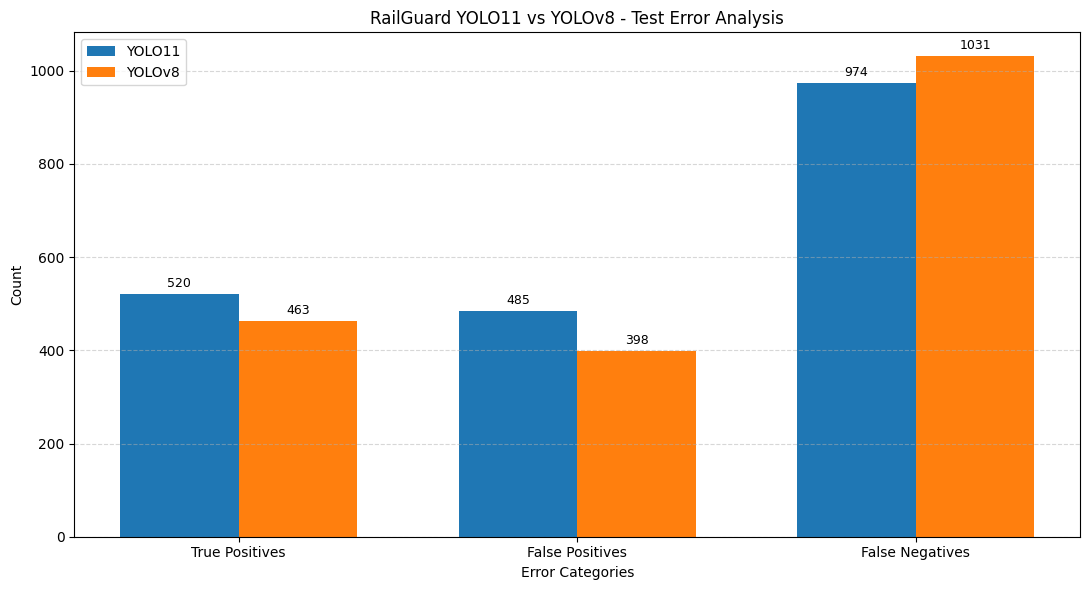

In [7]:
metric_names = [
    "True Positives",
    "False Positives",
    "False Negatives"
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(11, 6))

for i, model in enumerate(models):
    values = error_analysis.loc[
        error_analysis["Model"] == model,
        metric_names
    ].values[0]

    bars = plt.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 15,
            str(value),
            ha="center",
            fontsize=9
        )

plt.xticks(x, metric_names)
plt.ylabel("Count")
plt.xlabel("Error Categories")
plt.title("RailGuard YOLO11 vs YOLOv8 - Test Error Analysis")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
## Final Model Comparison

In [8]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "mAP@50",
        "mAP@50-95"
    ],
    "YOLO11": [
        0.477,
        0.406,
        0.439,
        0.400,
        0.144
    ],
    "YOLOv8": [
        0.4316,
        0.4258,
        0.4287,
        0.3975,
        0.1372
    ]
})

final_comparison["Better Model"] = final_comparison.apply(
    lambda row: "YOLO11"
    if row["YOLO11"] > row["YOLOv8"]
    else "YOLOv8",
    axis=1
)

display(final_comparison)

,Metric,YOLO11,YOLOv8,Better Model
0,Precision,0.477,0.4316,YOLO11
1,Recall,0.406,0.4258,YOLOv8
2,F1 Score,0.439,0.4287,YOLO11
3,mAP@50,0.400,0.3975,YOLO11
4,mAP@50-95,0.144,0.1372,YOLO11


In [ ]:
## Model Configuration Comparison

In [9]:
configuration = pd.DataFrame({
    "Parameter": [
        "Architecture",
        "Pretrained Weights",
        "Epochs",
        "Image Size",
        "Batch Size",
        "Optimizer",
        "AMP",
        "Hardware",
        "Number of Classes"
    ],
    "YOLO11": [
        "YOLO11n",
        "yolo11n.pt",
        50,
        "640 × 640",
        16,
        "AdamW",
        "Enabled",
        "NVIDIA Tesla T4",
        1
    ],
    "YOLOv8": [
        "YOLOv8n",
        "yolov8n.pt",
        50,
        "640 × 640",
        16,
        "AdamW",
        "Enabled",
        "NVIDIA Tesla T4",
        1
    ]
})

display(configuration)

,Parameter,YOLO11,YOLOv8
0,Architecture,YOLO11n,YOLOv8n
1,Pretrained Weights,yolo11n.pt,yolov8n.pt
2,Epochs,50,50
3,Image Size,640 × 640,640 × 640
4,Batch Size,16,16
5,Optimizer,AdamW,AdamW
6,AMP,Enabled,Enabled
7,Hardware,NVIDIA Tesla T4,NVIDIA Tesla T4
8,Number of Classes,1,1
